In [24]:
import os
import pandas as pd
import numpy as np

In [25]:
os.chdir(r"C:\Users\admin\Desktop\10-academy\insurance-risk-analytics")

In [26]:
df = pd.read_csv(
    r"data\MachineLearningRating_v3.txt",
    sep="|",
    low_memory=False
)

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

In [28]:
df.isnull().sum()

UnderwrittenCoverID               0
PolicyID                          0
TransactionMonth                  0
IsVATRegistered                   0
Citizenship                       0
LegalType                         0
Title                             0
Language                          0
Bank                         145961
AccountType                   40232
MaritalStatus                  8259
Gender                         9536
Country                           0
Province                          0
PostalCode                        0
MainCrestaZone                    0
SubCrestaZone                     0
ItemType                          0
mmcode                          552
VehicleType                     552
RegistrationYear                  0
make                            552
Model                           552
Cylinders                       552
cubiccapacity                   552
kilowatts                       552
bodytype                        552
NumberOfDoors               

In [29]:
df_clean = df.copy()

In [30]:
num_cols = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

In [31]:
cat_cols = df_clean.select_dtypes(
    include=["object"]
).columns

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].mode()[0]
    )

C:\Users\admin\AppData\Local\Temp\ipykernel_30384\2777734065.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(


In [32]:
df_clean["VehicleAge"] = (
    2026 - df_clean["RegistrationYear"]
)

In [33]:
df_clean["HasClaim"] = (
    df_clean["TotalClaims"] > 0
).astype(int)

In [34]:
claims_df = df_clean[
    df_clean["TotalClaims"] > 0
]

In [35]:
important_cols = [
    "Province",
    "VehicleType",
    "Gender",
    "CoverType",
    "TotalPremium",
    "VehicleAge"
]

In [36]:
X = claims_df[important_cols]

y = claims_df["TotalClaims"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = [
    "TotalPremium",
    "VehicleAge"
]

cat_cols = [
    "Province",
    "VehicleType",
    "Gender",
    "CoverType"
]

preprocess = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        num_cols
    ),

    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore")
            )
        ]),
        cat_cols
    )
])

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = [
    "TotalPremium",
    "VehicleAge"
]

cat_cols = [
    "Province",
    "VehicleType",
    "Gender",
    "CoverType"
]

preprocess = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        num_cols
    ),

    (
        "cat",
        Pipeline([
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "encoder",
                OneHotEncoder(handle_unknown="ignore")
            )
        ]),
        cat_cols
    )
])

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ("preprocess", preprocess),

    ("model",
     RandomForestRegressor(
         n_estimators=50,
         max_depth=10,
         random_state=42
     ))
])

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [41]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [42]:
from xgboost import XGBRegressor

xgb = Pipeline([
    ("preprocess", preprocess),

    ("model",
     XGBRegressor(
         n_estimators=50,
         learning_rate=0.1,
         random_state=42
     ))
])

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [43]:
from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

def evaluate_model(y_true, y_pred, name):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(name)
    print("RMSE:", rmse)
    print("R2:", r2)
    print()

In [44]:
from sklearn.linear_model import LinearRegression

lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [46]:
evaluate_model(y_test, lr_pred, "Linear Regression")

evaluate_model(y_test, rf_pred, "Random Forest")

evaluate_model(y_test, xgb_pred, "XGBoost")

Linear Regression
RMSE: 33783.60587929489
R2: 0.2903258490802044

Random Forest
RMSE: 34980.03838755441
R2: 0.23917014427629513

XGBoost
RMSE: 35229.297162658026
R2: 0.22828855567954165



In [47]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],

    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

results

,Model,RMSE,R2
0,Linear Regression,33783.605879,0.290326
1,Random Forest,34980.038388,0.239170
2,XGBoost,35229.297163,0.228289


In [48]:
X_class = df_clean[important_cols]

y_class = df_clean["HasClaim"]

In [49]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [51]:
from sklearn.ensemble import RandomForestClassifier

clf = Pipeline([
    ("preprocess", preprocess),

    ("model",
     RandomForestClassifier(
         n_estimators=50,
         max_depth=10,
         random_state=42
     ))
])

clf.fit(X_train_c, y_train_c)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [52]:
pred_class = clf.predict(X_test_c)

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy:", accuracy_score(y_test_c, pred_class))

print("Precision:", precision_score(y_test_c, pred_class))

print("Recall:", recall_score(y_test_c, pred_class))

print("F1:", f1_score(y_test_c, pred_class))

Accuracy: 0.9970952904709529
Precision: 0.0
Recall: 0.0


c:\Users\admin\Desktop\10-academy\insurance-risk-analytics\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


F1: 0.0


In [54]:
predicted_probability = clf.predict_proba(
    X_test_c
)[:,1]

In [56]:
from xgboost import XGBRegressor

xgb = Pipeline([
    ("preprocess", preprocess),

    ("model",
     XGBRegressor(
         n_estimators=50,
         learning_rate=0.1,
         random_state=42
     ))
])

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [58]:
important_cols = [
    "Province",
    "VehicleType",
    "Gender",
    "CoverType",
    "TotalPremium"
]

X_class = df_clean[important_cols]

y_class = df_clean["HasClaim"]

In [59]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = ["TotalPremium"]

cat_cols = [
    "Province",
    "VehicleType",
    "Gender",
    "CoverType"
]

preprocess = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        num_cols
    ),

    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cat_cols
    )
])

In [61]:
from sklearn.ensemble import RandomForestClassifier

clf = Pipeline([
    ("preprocess", preprocess),

    (
        "model",
        RandomForestClassifier(
            n_estimators=50,
            max_depth=10,
            random_state=42
        )
    )
])

In [62]:
clf.fit(X_train_c, y_train_c)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [63]:
predicted_probability = clf.predict_proba(X_test_c)[:,1]

In [65]:
predicted_probability = clf.predict_proba(
    X_test_c
)[:,1]

In [66]:
predicted_severity = xgb.predict(X_test)

In [67]:
premium = (
    predicted_probability[:len(predicted_severity)]
    * predicted_severity
) + 500 + 300

premium[:10]

array([800.32439756, 801.25009845, 810.73167918, 801.41057713,
       800.32263708, 863.90889164, 805.39625787, 800.30739383,
       800.45151642, 962.28017439])

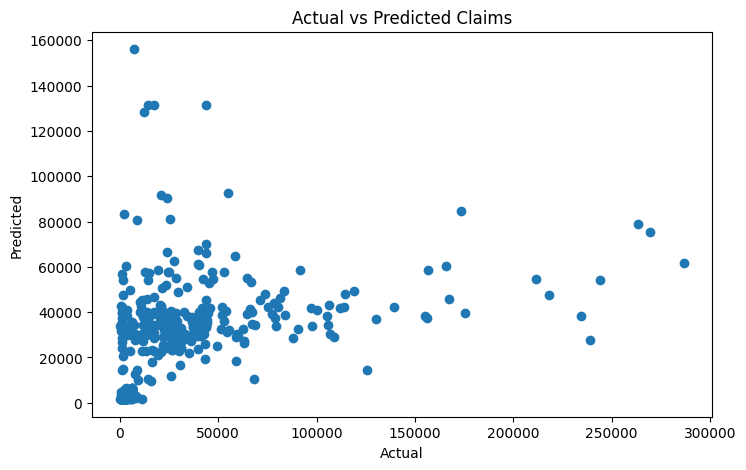

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, xgb_pred)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted Claims")

plt.show()

In [69]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [70]:
import shap

In [71]:
xgb_model = xgb.named_steps["model"]

X_processed = preprocess.fit_transform(X_train)

In [73]:
explainer = shap.Explainer(xgb_model)

In [76]:
print(X_train.shape)
print(X_test.shape)

(2230, 6)
(558, 6)


In [80]:
X_train_processed = preprocess.fit_transform(X_train)

X_test_processed = preprocess.transform(X_test)

In [81]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [82]:
xgb_pred = xgb_model.predict(X_test_processed)

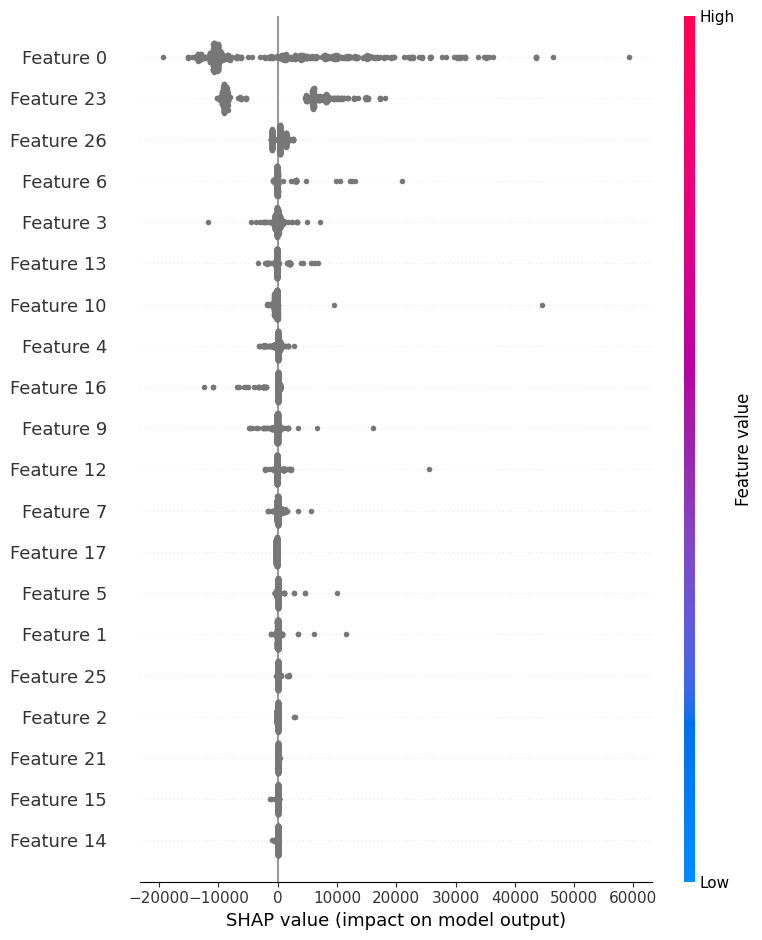

In [83]:
import shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(shap_values, X_test_processed)